#  Proyecto de Detección de Fraude: Detección de Fraude en Transacciones Financieras

**Autor:** DENISLMO 
**Tipo:** Aprendizaje Supervisado (Clasificación Binaria)

## Objetivo de Negocio

Identificar transacciones fraudulentas en tiempo real para minimizar pérdidas financieras y proteger a los clientes.

## PASO 0: Importación de datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuración de rutas
PATH_TRAIN = '../data/fraudTrain.csv'
PATH_TEST = '../data/fraudTest.csv'
# Carga de datos
df_train = pd.read_csv(PATH_TRAIN, index_col=0)
df_test = pd.read_csv(PATH_TEST, index_col=0)

# Verificamos etiqueta 'is_fraud' 
print(f"Total transacciones: {len(df_train)}")
print(df_train['is_fraud'].value_counts())

Total transacciones: 1296675
is_fraud
0    1289169
1       7506
Name: count, dtype: int64


## Paso 1: Fix de desbalanceo 

C:\Users\DENISLMO\AppData\Local\Temp\ipykernel_11868\4280832602.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraud_counts.index, y=fraud_counts.values, palette='magma')


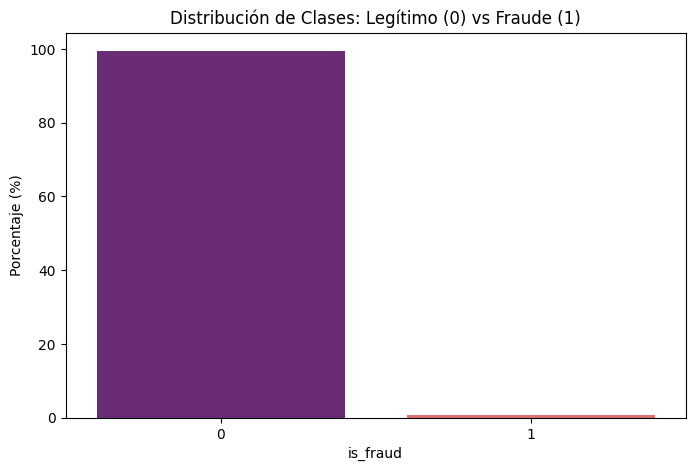

El fraude representa solo el 0.58% de las transacciones.


In [2]:
# Cálculo del desbalanceo
fraud_counts = df_train['is_fraud'].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 5))
sns.barplot(x=fraud_counts.index, y=fraud_counts.values, palette='magma')
plt.title('Distribución de Clases: Legítimo (0) vs Fraude (1)')
plt.ylabel('Porcentaje (%)')
plt.show()


print(f'El fraude representa solo el {fraud_counts[1]:.2f}% de las transacciones.')

## Paso 2: Feature Engineering (Ingeniería de Sospecha)

Para que el modelo detecte patrones, transformamos datos brutos en "señales de alerta":
1. **Distancia Haversine:** Kilómetros entre la ubicación del cliente y el comercio.
2. **Ciclos Temporales:** Extracción de hora y día para detectar patrones nocturnos.
3. **Perfil Demográfico:** Cálculo de la edad del titular en el momento de la transacción.

Para normalizar estas magnitudes y que el modelo no se sesgue por valores grandes como el monto (`amt`), aplicaremos **Standard Scaling**:

$$z = \frac{x - \mu}{\sigma}$$

In [3]:
import sys 
import os
sys.path.append(os.path.join(os.getcwd(), '..'))
from src.processor import preprocess_data

# Aplicamos la lógica definida en nuestro script de src

train_clean = preprocess_data(df_train)
test_clean = preprocess_data(df_test)

# Verificamos el resultado
print(train_clean.head())

      amt  distancia_km  hora  dia_semana  edad  is_fraud
0    4.97     78.597568     0           1    30         0
1  107.23     30.212176     0           1    40         0
2  220.11    108.206083     0           1    56         0
3   45.00     95.673231     0           1    52         0
4   41.96     77.556744     0           1    32         0


## Paso 3: Balanceo de Clases (SMOTE)

Dada la escasez de ejemplos de fraude (0.58%), utilizaremos **SMOTE** (Synthetic Minority Over-sampling Technique). Esta técnica genera ejemplos sintéticos de la clase minoritaria basándose en sus vecinos más cercanos, permitiendo que el modelo aprenda la frontera de decisión del fraude sin simplemente memorizar datos.

In [7]:
from imblearn.over_sampling import SMOTE
from src.model import FraudModel

model_wrapper = FraudModel()

#  Entrenamos con los datos balanceados por SMOTE
model_wrapper.train(X_resampled, y_resampled)

#  Evaluamos con los datos de TEST (que no tienen SMOTE, son datos reales)
# Pre-procesamos el test primero
X_test = test_clean.drop('is_fraud', axis=1)
y_test = test_clean['is_fraud']

model_wrapper.evaluate(X_test, y_test)

#  Guardamos para la App
model_wrapper.save_model('../models/fraud_model.pkl')
print("Modelo entrenado y guardado en /models")

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    553574
           1       0.22      0.71      0.34      2145

    accuracy                           0.99    555719
   macro avg       0.61      0.85      0.67    555719
weighted avg       1.00      0.99      0.99    555719

✅ Modelo entrenado y guardado en /models
